In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_train_data
from src.data.preprocess import (
    preprocess_train, clean_text,
    remove_urls, remove_html, remove_ip_addresses,
    remove_wikipedia_artifacts, normalize_profanity,
    normalize_repeated_chars, remove_non_ascii,
    remove_numbers, clean_punctuation,
    remove_stopwords, lemmatize_text
)

df_raw = load_train_data()
df_clean = preprocess_train(df_raw.copy())

In [4]:
# pick a toxic comment that has URLs, HTML, profanity etc.
sample = df_raw[df_raw['toxic'] == 1]['comment_text'].iloc[1]

steps = [
    ("Original",                    sample),
    ("Lowercased",                  sample.lower()),
    ("Remove IPs",                  remove_ip_addresses(sample.lower())),
    ("Remove URLs",                 remove_urls(remove_ip_addresses(sample.lower()))),
    ("Remove HTML",                 remove_html(remove_urls(remove_ip_addresses(sample.lower())))),
    ("Remove Wikipedia artifacts",  remove_wikipedia_artifacts(remove_html(remove_urls(remove_ip_addresses(sample.lower()))))),
    ("Normalize profanity",         normalize_profanity(remove_wikipedia_artifacts(remove_html(remove_urls(remove_ip_addresses(sample.lower())))))),
    ("Normalize repeated chars",    normalize_repeated_chars(normalize_profanity(remove_wikipedia_artifacts(remove_html(remove_urls(remove_ip_addresses(sample.lower()))))))),
    ("Remove non-ASCII",            remove_non_ascii(normalize_repeated_chars(normalize_profanity(remove_wikipedia_artifacts(remove_html(remove_urls(remove_ip_addresses(sample.lower())))))))),
    ("Remove numbers",              remove_numbers(remove_non_ascii(normalize_repeated_chars(normalize_profanity(remove_wikipedia_artifacts(remove_html(remove_urls(remove_ip_addresses(sample.lower()))))))))),
    ("Clean punctuation",           clean_punctuation(remove_numbers(remove_non_ascii(normalize_repeated_chars(normalize_profanity(remove_wikipedia_artifacts(remove_html(remove_urls(remove_ip_addresses(sample.lower())))))))))),
    ("Final (clean_text)",          clean_text(sample)),
]

print("=" * 80)
for step_name, result in steps:
    print(f"\n📌 {step_name}:\n{result[:300]}")
    print("-" * 80)


📌 Original:
Hey... what is it..
@ | talk .
What is it... an exclusive group of some WP TALIBANS...who are good at destroying, self-appointed purist who GANG UP any one who asks them questions abt their ANTI-SOCIAL and DESTRUCTIVE (non)-contribution at WP?

Ask Sityush to clean up his behavior than issue me nons
--------------------------------------------------------------------------------

📌 Lowercased:
hey... what is it..
@ | talk .
what is it... an exclusive group of some wp talibans...who are good at destroying, self-appointed purist who gang up any one who asks them questions abt their anti-social and destructive (non)-contribution at wp?

ask sityush to clean up his behavior than issue me nons
--------------------------------------------------------------------------------

📌 Remove IPs:
hey... what is it..
@ | talk .
what is it... an exclusive group of some wp talibans...who are good at destroying, self-appointed purist who gang up any one who asks them questions abt their ant

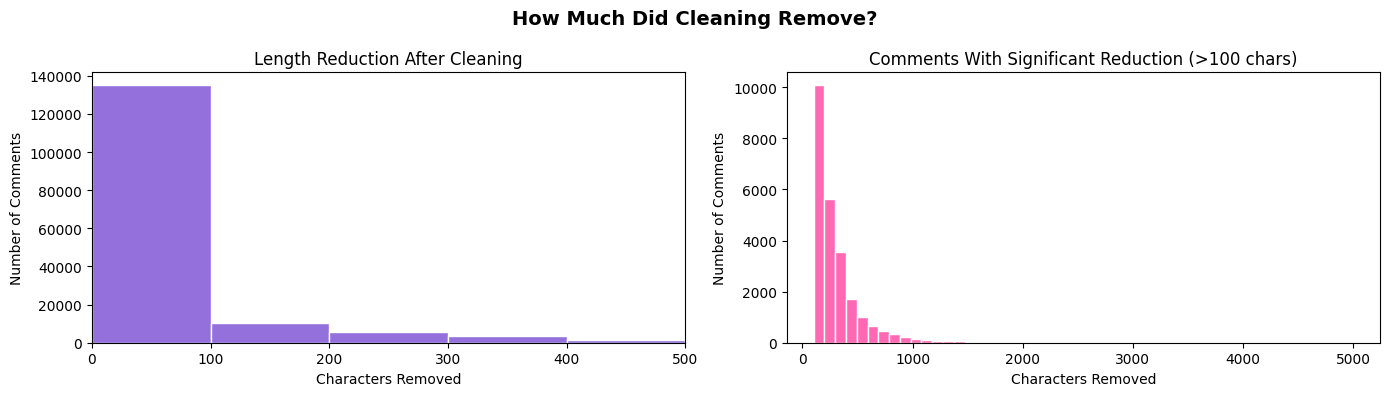

Average characters removed: 65.4
Max characters removed:     5000
Comments unchanged:         4424
Comments shortened >100chars: 24370


In [5]:
df_raw['raw_length'] = df_raw['comment_text'].apply(len)
df_clean['clean_length'] = df_clean['comment_text'].apply(len)
length_diff = df_raw['raw_length'] - df_clean['clean_length']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(length_diff, bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('Length Reduction After Cleaning')
axes[0].set_xlabel('Characters Removed')
axes[0].set_ylabel('Number of Comments')
axes[0].set_xlim(0, 500)

axes[1].hist(length_diff[length_diff > 100], bins=50, color='hotpink', edgecolor='white')
axes[1].set_title('Comments With Significant Reduction (>100 chars)')
axes[1].set_xlabel('Characters Removed')
axes[1].set_ylabel('Number of Comments')

plt.suptitle('How Much Did Cleaning Remove?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average characters removed: {length_diff.mean():.1f}")
print(f"Max characters removed:     {length_diff.max()}")
print(f"Comments unchanged:         {(length_diff == 0).sum()}")
print(f"Comments shortened >100chars: {(length_diff > 100).sum()}")

In [6]:
import re

def was_normalized(raw, cleaned):
    return raw.lower() != cleaned

profanity_patterns = [
    r'f[\W_]*u[\W_]*c[\W_]*k+',
    r's[\W_]*h[\W_]*i[\W_]*t+',
    r'b[\W_]*i[\W_]*t[\W_]*c[\W_]*h+',
    r'a[\W_]*s[\W_]*s+',
]

# find comments where profanity normalization actually fired
mask = df_raw['comment_text'].apply(
    lambda x: any(re.search(p, x, re.IGNORECASE) for p in profanity_patterns)
)

examples = df_raw[mask].head(5)
print("PROFANITY NORMALIZATION EXAMPLES")
print("=" * 80)
for _, row in examples.iterrows():
    raw = row['comment_text'][:300]
    cleaned = clean_text(row['comment_text'])[:300]
    print(f"\n BEFORE: {raw}")
    print(f"\n AFTER:  {cleaned}")
    print("-" * 80)

PROFANITY NORMALIZATION EXAMPLES

 BEFORE: Oh, and the girl above started her arguments with me. She stuck her nose where it doesn't belong. I believe the argument was between me and Yvesnimmo. But like I said, the situation was settled and I apologized. Thanks,

 AFTER:  oh and the girl above started her arguments with me she stuck her nose where it doesnt belong i believe the argument was between me and yvesnimmo but like i said the situation wassettled and i apologized thanks
--------------------------------------------------------------------------------

 BEFORE: "

Juelz Santanas Age

In 2002, Juelz Santana was 18 years old, then came February 18th, which makes Juelz turn 19 making songs with The Diplomats. The third neff to be signed to Cam's label under Roc A Fella. In 2003, he was 20 years old coming out with his own singles ""Santana's Town"" and ""Down

 AFTER:  juelz santanas age in juelz santana was years old then came february th which makes juelz turn making songs with t

In [7]:
short = df_clean[df_clean['comment_text'].str.split().str.len() < 3]

print(f"Comments with fewer than 3 words after cleaning: {len(short)}")
print(f"That's {len(short)/len(df_clean)*100:.2f}% of the dataset\n")

if len(short) > 0:
    print("Examples:")
    print("=" * 80)
    for _, row in short.head(10).iterrows():
        original = df_raw.loc[row.name, 'comment_text'][:200]
        print(f"\n ORIGINAL: {original}")
        print(f" CLEANED:  '{row['comment_text']}'")
        print("-" * 80)

Comments with fewer than 3 words after cleaning: 3691
That's 2.31% of the dataset

Examples:

 ORIGINAL: REDIRECT Talk:Voydan Pop Georgiev- Chernodrinski
 CLEANED:  'redirect'
--------------------------------------------------------------------------------

 ORIGINAL: REDIRECT Talk:Frank Herbert Mason
 CLEANED:  'redirect'
--------------------------------------------------------------------------------

 ORIGINAL: 86.29.244.57|86.29.244.57]] 04:21, 14 May 2007
 CLEANED:  'may'
--------------------------------------------------------------------------------

 ORIGINAL: 2005 (UTC)

  15:59, 17 December
 CLEANED:  'utc december'
--------------------------------------------------------------------------------

 ORIGINAL: REDIRECT Talk:List of South Carolina Stingrays seasons
 CLEANED:  'redirect'
--------------------------------------------------------------------------------

 ORIGINAL: Fuck you 

-User:The Bohemian Shinobis yeah, that's right, bitch! You are all pieces of shit!
 CLEANED:

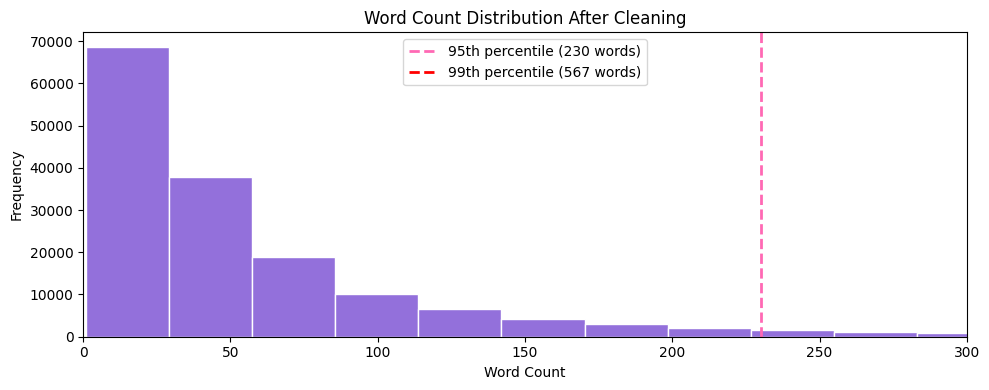

Word count percentiles (for setting max_len in LSTM/RNN):
  50th: 36 words
  75th: 75 words
  90th: 152 words
  95th: 230 words  ← recommended max_len
  99th: 567 words


In [8]:
percentiles = df_clean['word_count'].quantile([0.5, 0.75, 0.90, 0.95, 0.99])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_clean['word_count'], bins=50, color='mediumpurple', edgecolor='white')
ax.axvline(percentiles[0.95], color='hotpink', linestyle='--', linewidth=2, label=f"95th percentile ({int(percentiles[0.95])} words)")
ax.axvline(percentiles[0.99], color='red', linestyle='--', linewidth=2, label=f"99th percentile ({int(percentiles[0.99])} words)")
ax.set_title('Word Count Distribution After Cleaning')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)
ax.legend()
plt.tight_layout()
plt.show()

print("Word count percentiles (for setting max_len in LSTM/RNN):")
print(f"  50th: {int(percentiles[0.50])} words")
print(f"  75th: {int(percentiles[0.75])} words")
print(f"  90th: {int(percentiles[0.90])} words")
print(f"  95th: {int(percentiles[0.95])} words  ← recommended max_len")
print(f"  99th: {int(percentiles[0.99])} words")